<a href="https://colab.research.google.com/github/pedromp-hub/Practica-Teachable-Machine/blob/main/TeachableMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DOCUMENTACIÓN TEACHABLE MACHINE**

1. Entrenamiento en Teachable Machine

- Entramos en la web y subimos las fotos de los objetos que queremos que la IA distinga.
- Entrenamos la IA para que aprenda a diferenciarlas.
- Exportamos el modelo eligiendo la opción TensorFlow.js y descargamos el archivo comprimido zip.

2. Organización de archivos locales

- Descomprimimos el archivo zip y obtendremos los siguientes archivos que tienen que estar colocados en una carpeta que nosotros creemos de la siguiente forma.

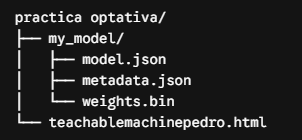


3. Carga y Ejecución del HTML
```
- Petición al servidor local: Cuando abres teachablemachinepedro.html mediante un servidor local
(como Live Server en VS Code), el navegador lee el documento.
- Importación de librerías: En las etiquetas <script src="..."> de la cabecera, el navegador
descarga la librería pública de TensorFlow.js y la de Teachable Machine, necesarias para
procesar redes neuronales en el navegador.
- Carga del modelo (init()):

Se ejecuta la función tmImage.load("./my_model/model.json", "./my_model/metadata.json").

El navegador lee la arquitectura y descarga el archivo pesado weights.bin a la memoria RAM.
```

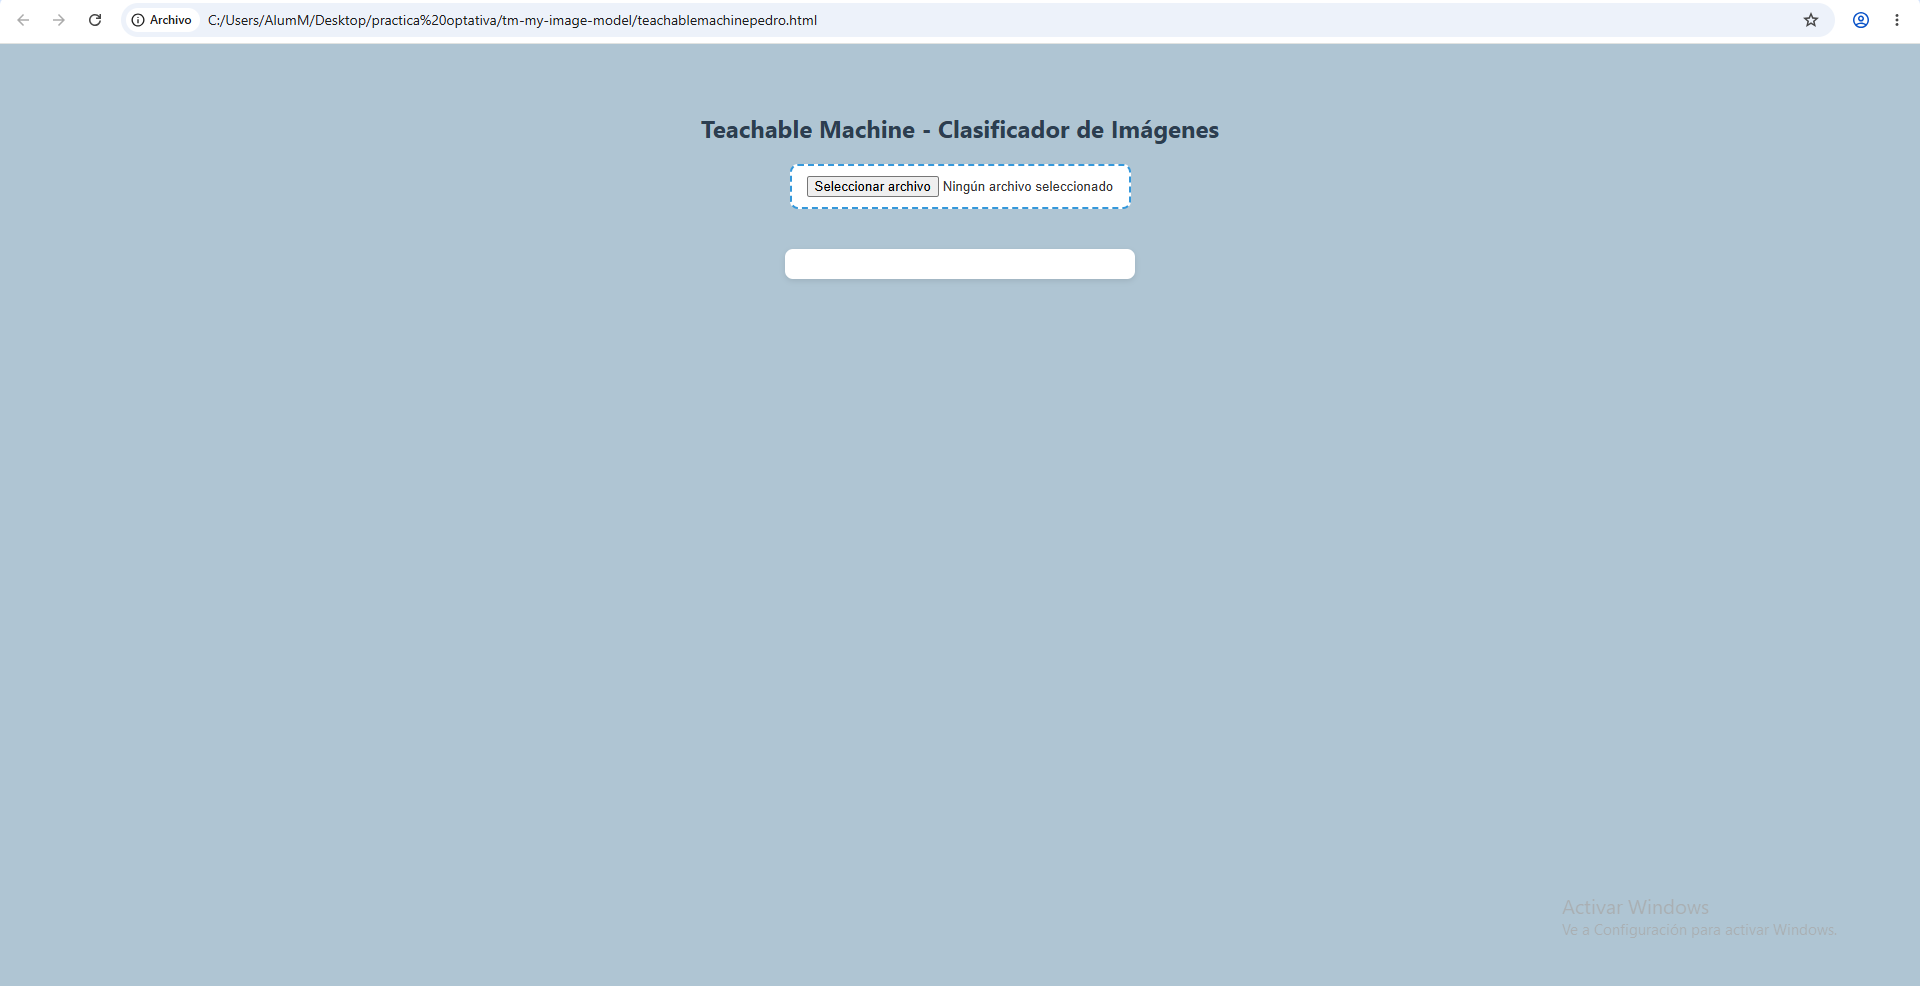


```
4. Selección y lectura de la imagen

- Entrada de datos (<input type="file">): Al presionar el botón y seleccionar una foto de
tu ordenador, JavaScript detecta el evento onchange y llama a predictImage().
- Creación del objeto visual: Con window.URL.createObjectURL(file), JavaScript genera
una representación en memoria de esa foto y la muestra
dentro del bloque <div id="image-container">.
```
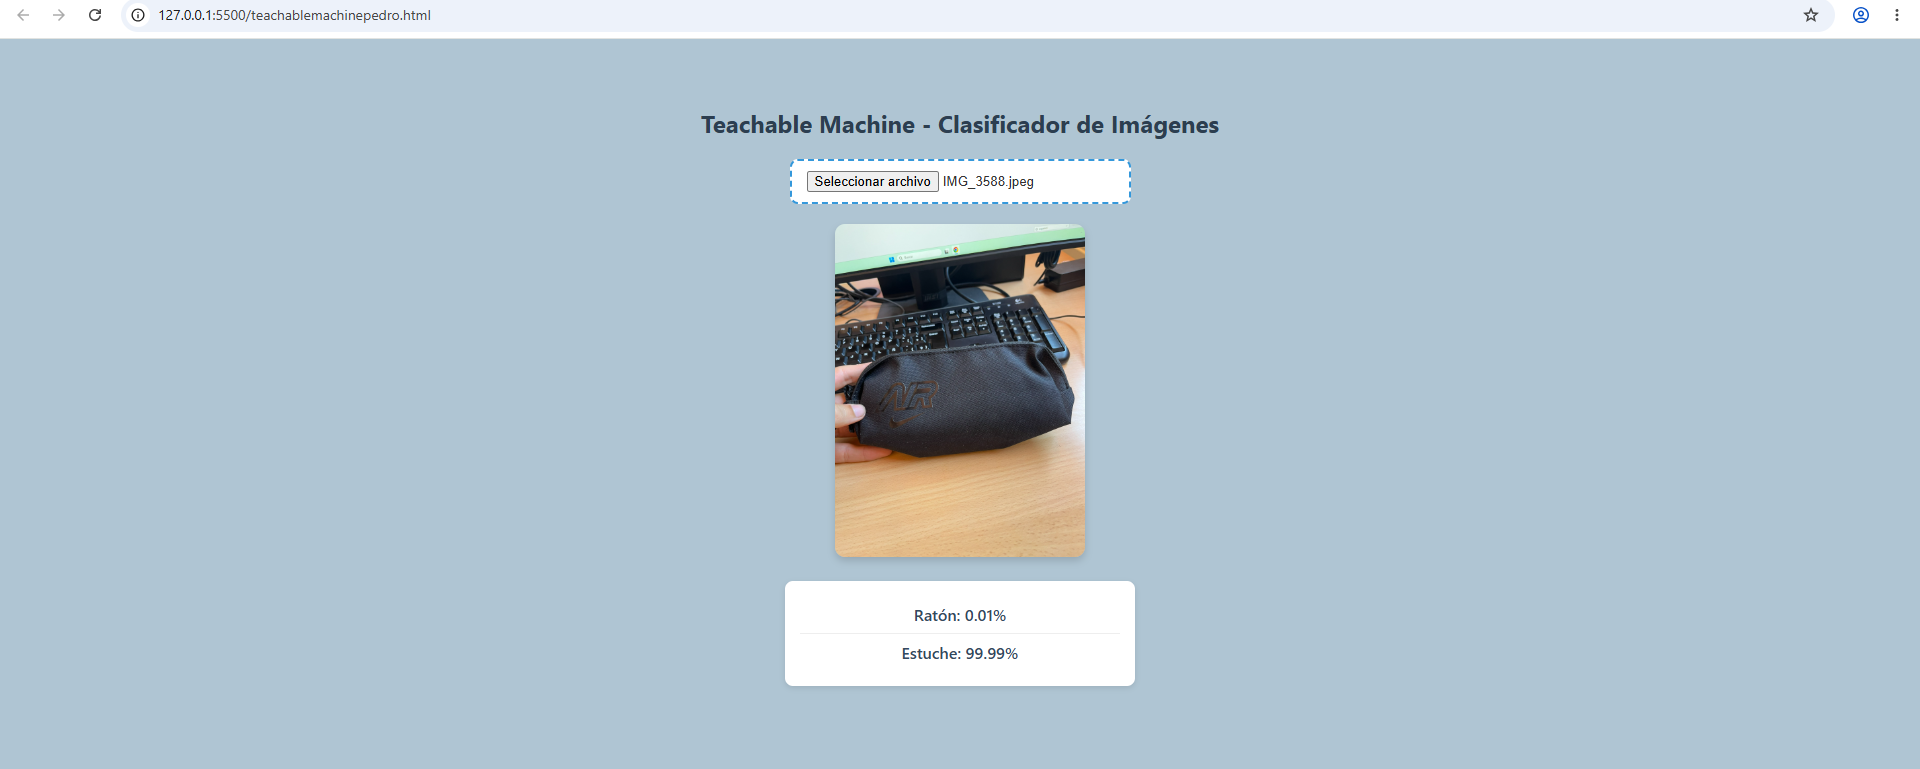

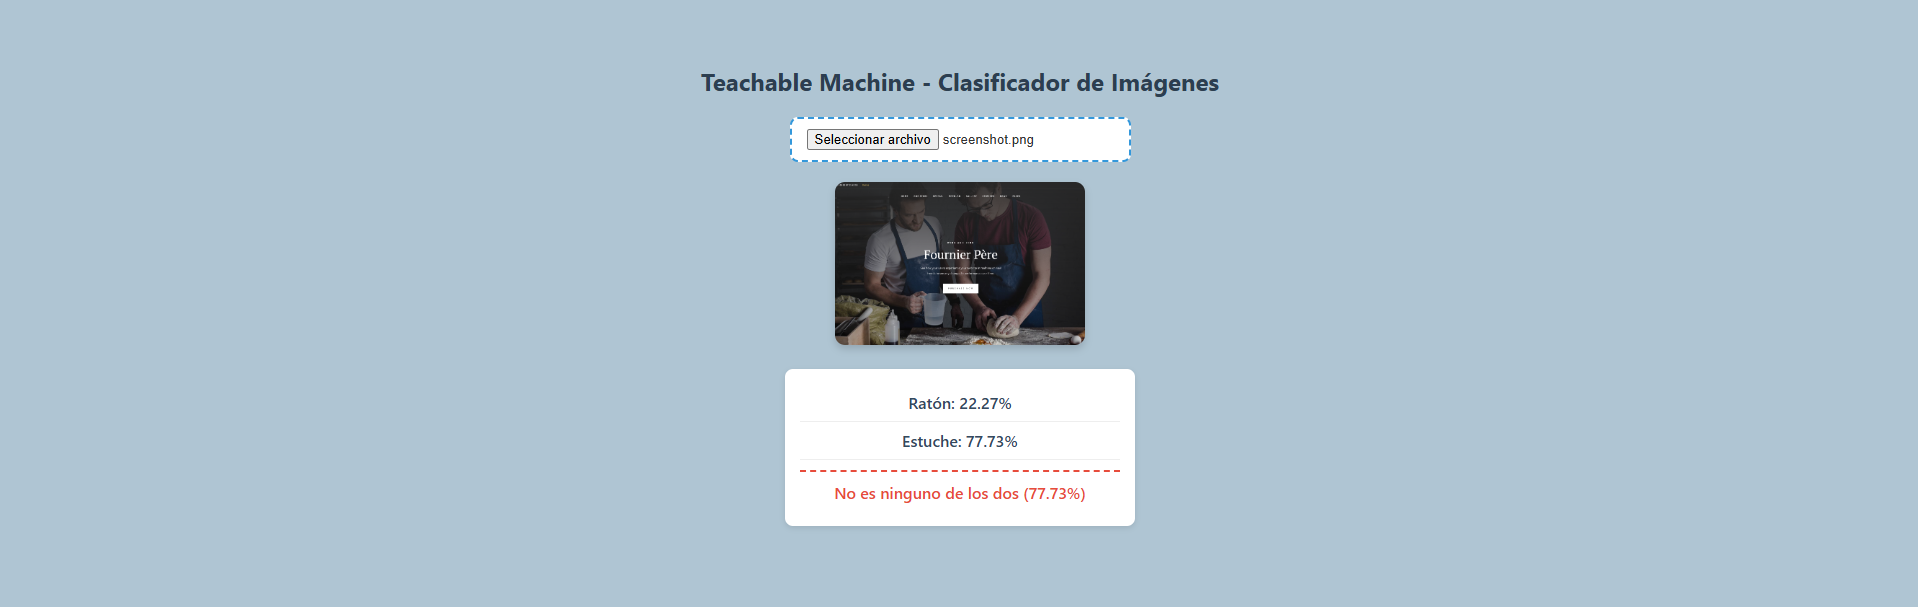

5. Código
```
<!DOCTYPE html>
<html>
<head>
  <meta charset="UTF-8">
  <title>Teachable Machine - Clasificador</title>
  
  <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>

  <style>
    body {
      font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
      background-color: #f4f7f6;
      display: flex;
      flex-direction: column;
      align-items: center;
      padding: 40px 20px;
      color: #333;
      background-color: #afc5d3;
    }

    h2 {
      color: #2c3e50;
      margin-bottom: 20px;
    }

    input[type="file"] {
      padding: 10px 15px;
      background-color: #ffffff;
      border: 2px dashed #3498db;
      border-radius: 8px;
      cursor: pointer;
      margin-bottom: 20px;
    }

    #image-container {
      margin-bottom: 20px;
    }

    #image-container img {
      border-radius: 10px;
      box-shadow: 0 4px 8px rgba(0, 0, 0, 0.15);
    }

    #label-container {
      width: 100%;
      max-width: 320px;
      background: white;
      padding: 15px;
      border-radius: 8px;
      box-shadow: 0 2px 6px rgba(0, 0, 0, 0.1);
      text-align: center;
    }

    #label-container div {
      padding: 8px 0;
      border-bottom: 1px solid #eee;
      font-weight: 600;
      color: #34495e;
    }

    #label-container div:last-child {
      border-bottom: none;
    }

    .warning-message {
      color: #e74c3c !important;
      font-weight: bold;
      margin-top: 10px;
      padding-top: 10px !important;
      border-top: 2px dashed #e74c3c !important;
    }
  </style>
</head>
<body>

  <h2>Teachable Machine - Clasificador de Imágenes</h2>
  
  <input type="file" id="image-input" accept="image/*" onchange="predictImage()">

  <div id="image-container"></div>
  <div id="label-container"></div>

  <script type="text/javascript">
    const URL = "./my_model/";

    let model, labelContainer, maxPredictions;

    async function init() {
        const modelURL = URL + "model.json";
        const metadataURL = URL + "metadata.json";

        model = await tmImage.load(modelURL, metadataURL);
        maxPredictions = model.getTotalClasses();

        labelContainer = document.getElementById("label-container");
    }

    async function predictImage() {
        if (!model) await init();

        const input = document.getElementById("image-input");
        if (input.files && input.files[0]) {
            const file = input.files[0];
            const img = document.createElement("img");
            img.src = window.URL.createObjectURL(file);
            img.width = 250;
            
            img.onload = async function() {
                const imageContainer = document.getElementById("image-container");
                imageContainer.innerHTML = "";
                imageContainer.appendChild(img);

                const prediction = await model.predict(img);
                
                labelContainer.innerHTML = ""; // Limpiar resultados anteriores

                let highestProbability = 0;

                // 1. Mostrar siempre los porcentajes de ambas clases
                for (let i = 0; i < maxPredictions; i++) {
                    const classDiv = document.createElement("div");
                    const percentage = (prediction[i].probability * 100).toFixed(2);
                    classDiv.innerHTML = prediction[i].className + ": " + percentage + "%";
                    labelContainer.appendChild(classDiv);

                    if (prediction[i].probability > highestProbability) {
                        highestProbability = prediction[i].probability;
                    }
                }

                // 2. Mostrar el mensaje debajo si la clase más alta no llega al 95%
                if (highestProbability < 0.95) {
                    const highestPercentage = (highestProbability * 100).toFixed(2);
                    const noMatchDiv = document.createElement("div");
                    noMatchDiv.className = "warning-message";
                    noMatchDiv.innerHTML = "No es ninguno de los dos (" + highestPercentage + "%)";
                    labelContainer.appendChild(noMatchDiv);
                }
            };
        }
    }

    init();
  </script>
</body>
</html>
```



6. Conclusión

El flujo de trabajo que hemos implementado consiste en entrenar un modelo de aprendizaje automático en Teachable Machine, exportar sus componentes estructurales y de pesos a una carpeta local, y cargarlos en una aplicación web mediante TensorFlow.js. Al seleccionar una imagen desde tu ordenador, el navegador la procesa en memoria y la transfiere al modelo para calcular la probabilidad de pertenencia a cada clase. Finalmente, una lógica en JavaScript evalúa el porcentaje de certeza obtenido: muestra las probabilidades de cada categoría y, si el valor máximo es inferior al 95%, despliega automáticamente un mensaje que indica que la imagen no pertenece a ninguna de las opciones entrenadas.

